# P1 · PPI Network Analysis
**Input :** `data/processed/dea_results.csv`  
**Outputs:** `results/tables/hub_genes.csv` · `results/tables/ppi_edges_cytoscape.csv` · `results/figures/ppi_network.png`

Queries the STRING database, builds a protein–protein interaction network from
the significant DEGs, and ranks genes by composite centrality (hub score).
The hub score is used as a node feature in the GNN (notebook P4).

**Run order:** 01 → 02 → 03 → 04 → **P1** → P2 → P3 → P4


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from paths import REPO_ROOT, PROC_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Tables    : {TABLES_DIR}")
print(f"Figures   : {FIGURES_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Tables    : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\tables
Figures   : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures


In [3]:
import sys
sys.path.insert(0, str(REPO_ROOT / "scripts"))
from utils import build_ppi_graph, compute_hub_scores, plot_ppi_network

import time, requests
import numpy as np, pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("Imports OK")

Imports OK


In [4]:
STRING_SCORE  = 400    # 400=medium, 700=high confidence
LOG2FC_THRESH = 1.0
PADJ_THRESH   = 0.05
TOP_VIZ_NODES = 80     # nodes shown in PPI network figure

## Load & filter DEA results

In [5]:
dea = pd.read_csv(PROC_DIR / "dea_results.csv")
sig = dea[(dea.adj_pvalue < PADJ_THRESH) & (dea.log2FC.abs() >= LOG2FC_THRESH)].copy()
sig["regulation"] = (sig.log2FC > 0).map({True:"up", False:"down"})
gene_list = sig.gene.dropna().unique().tolist()

print(f"DEGs loaded   : {len(sig)}")
print(f"  Upregulated : {(sig.regulation=='up').sum()}")
print(f"  Downregulated: {(sig.regulation=='down').sum()}")
print(f"  Unique genes : {len(gene_list)}")
sig.head()

DEGs loaded   : 1385
  Upregulated : 335
  Downregulated: 1050
  Unique genes : 1385


,gene,log2FC,adj_pvalue,regulation
0,RPS26,1.991955,7.295115e-149,up
1,XIST,31.180847,2.625168e-118,up
2,MALAT1,1.089554,3.200503e-93,up
3,CREM,2.918553,7.829163e-81,up
4,JUND,1.322786,5.349000e-73,up


## Query STRING API

In [7]:
print("\n── Querying STRING API ──")
 
STRING_URL = "https://string-db.org/api/json/network"
 
# STRING accepts up to ~2000 genes per request
# Split into batches of 500 if needed
BATCH_SIZE = 1385
all_edges = []
 
for i in range(0, len(gene_list), BATCH_SIZE):
    batch = gene_list[i : i + BATCH_SIZE]
    print(f"  Querying batch {i // BATCH_SIZE + 1} ({len(batch)} genes)...")
 
    params = {
        "identifiers"       : "\r".join(batch),
        "species"           : 9606,           # Homo sapiens
        "required_score"    : STRING_SCORE,
        "network_type"      : "functional",   # or "physical"
        "caller_identity"   : "hcc_ppi_script",
    }
 
    try:
        resp = requests.post(STRING_URL, data=params, timeout=60)
        resp.raise_for_status()
        edges = resp.json()
        all_edges.extend(edges)
        print(f"    → {len(edges)} interactions returned")
    except requests.exceptions.RequestException as e:
        print(f"    ✗ Request failed: {e}")
        print("    Check your internet connection or try reducing batch size.")
        raise
 
    time.sleep(1)  # be polite to the API
 
if not all_edges:
    raise ValueError(
        "No interactions returned from STRING. "
        "Try lowering STRING_SCORE or checking gene names."
    )
 
# Build edge dataframe
edges_df = pd.DataFrame(all_edges)
 
# Keep only relevant columns (STRING field names vary slightly by version)
keep_cols = {
    "preferredName_A": "gene_A",
    "preferredName_B": "gene_B",
    "score":           "combined_score",
}
edges_df = edges_df.rename(columns=keep_cols)[list(keep_cols.values())]
 
# Remove self-loops and duplicates
edges_df = edges_df[edges_df["gene_A"] != edges_df["gene_B"]]
edges_df["pair"] = edges_df.apply(
    lambda r: tuple(sorted([r["gene_A"], r["gene_B"]])), axis=1
)
edges_df = edges_df.drop_duplicates("pair").drop(columns="pair")
edges_df["combined_score"] = pd.to_numeric(
    edges_df["combined_score"], errors="coerce"
)
 
print(f"\n  Total unique interactions: {len(edges_df)}")


── Querying STRING API ──
  Querying batch 1 (1385 genes)...
    → 18830 interactions returned

  Total unique interactions: 18830


## Build graph & compute hub scores

In [ ]:
G      = build_ppi_graph(sig, edges_df)
hub_df = compute_hub_scores(G, sig)

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"\nTop 10 hub genes:")
hub_df[["gene","degree","hub_score","regulation"]].head(10)

Nodes : 1254
Edges : 18267

Top 10 hub genes:


,gene,degree,hub_score,regulation
0,GAPDH,302,0.917152,down
1,CD4,266,0.765749,down
2,IL1B,253,0.739639,down
3,IFNG,236,0.722639,up
4,CD8A,225,0.688971,up
5,ALB,214,0.641123,down
6,TLR4,199,0.639746,down
7,IL10,188,0.602473,down
8,ITGAM,182,0.584034,down
9,CCL2,182,0.583749,down


## Visualise network

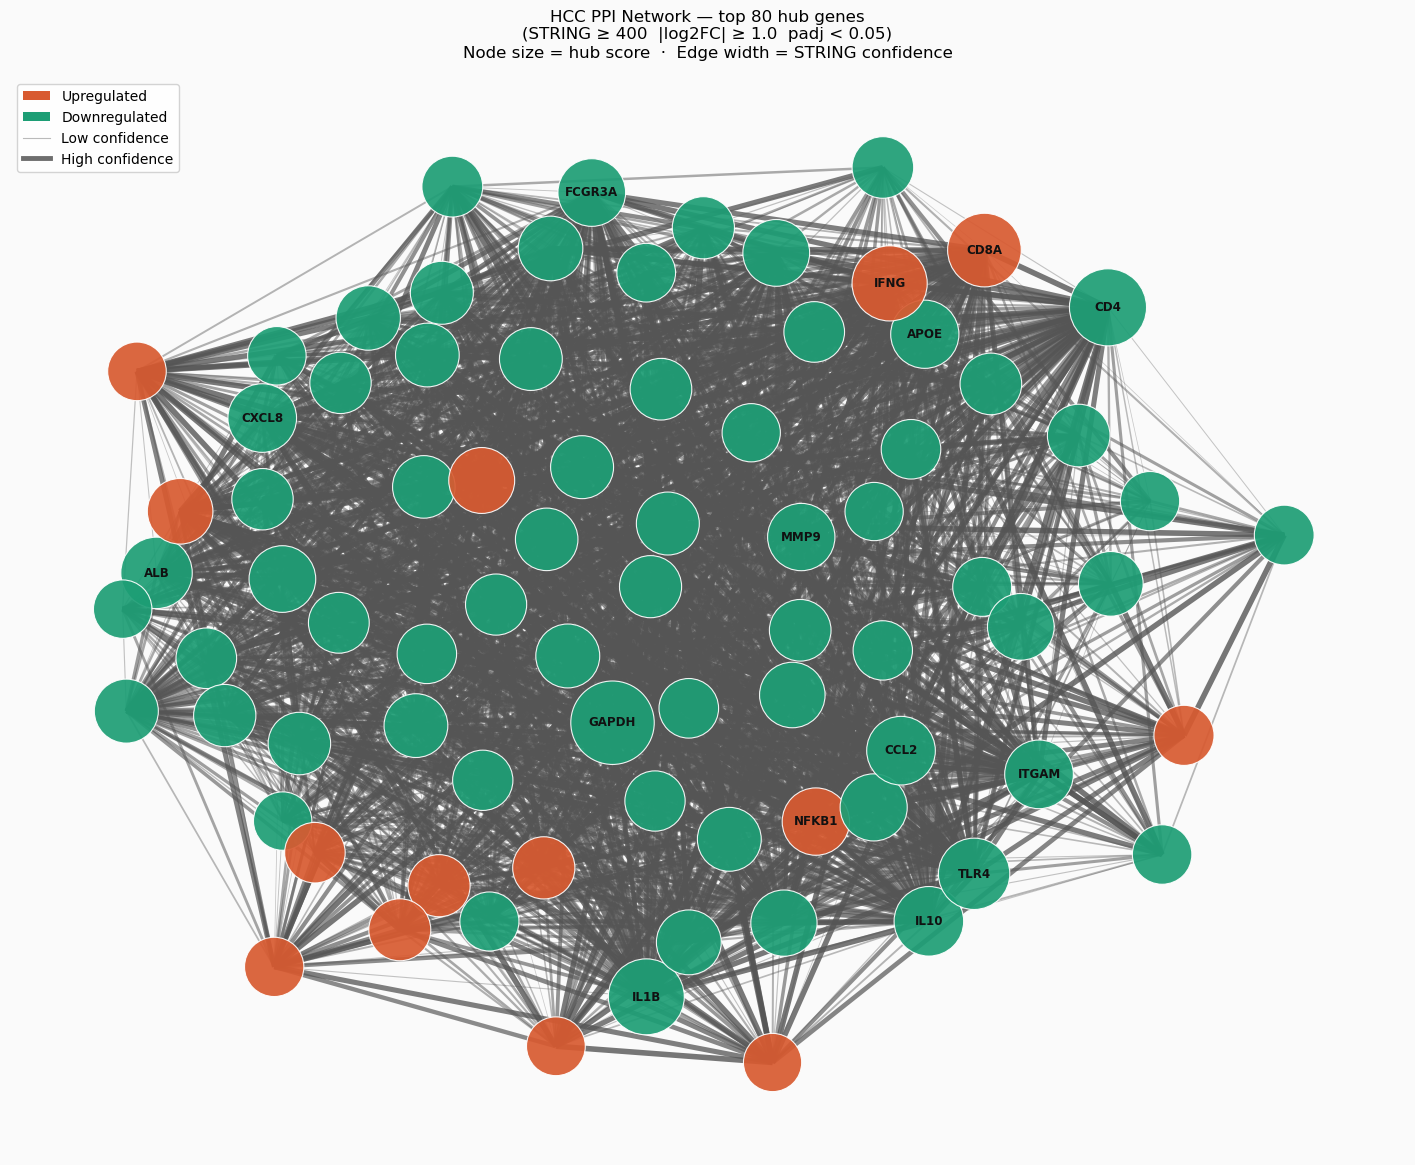

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/ppi_network.png


In [9]:
fig, _ = plot_ppi_network(
    G, hub_df,
    top_nodes=TOP_VIZ_NODES,
    string_score=STRING_SCORE,
    log2fc_thresh=LOG2FC_THRESH,
    padj_thresh=PADJ_THRESH,
)
fig.savefig(FIGURES_DIR / "ppi_network.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR}/ppi_network.png")

## Export

In [10]:
# Hub gene table → used as input by P3 (DGI) and P4 (GNN)
hub_cols = ["gene","degree","hub_score","deg_c","betweenness",
            "closeness","eigenvector","log2FC","adj_pvalue","regulation"]
hub_df[[c for c in hub_cols if c in hub_df.columns]].to_csv(
    TABLES_DIR / "hub_genes.csv", index=False)

# Cytoscape edge list
cyto = edges_df[
    edges_df.gene_A.isin(G.nodes()) & edges_df.gene_B.isin(G.nodes())
].copy()
cyto.rename(columns={"gene_A":"source","gene_B":"target",
                     "combined_score":"STRING_score"}, inplace=True)
cyto.to_csv(TABLES_DIR / "ppi_edges_cytoscape.csv", index=False)

print(f"Saved: hub_genes.csv            ({len(hub_df)} genes)")
print(f"Saved: ppi_edges_cytoscape.csv  ({len(cyto)} edges)")
print(f"\nTop 5 hub genes: {hub_df.gene.head().tolist()}")

Saved: hub_genes.csv            (1254 genes)
Saved: ppi_edges_cytoscape.csv  (18267 edges)

Top 5 hub genes: ['GAPDH', 'CD4', 'IL1B', 'IFNG', 'CD8A']
